In [6]:
from dotenv import load_dotenv
import os
import operator

from typing import TypedDict, Annotated
from pydantic import BaseModel, Field

from langgraph.graph import StateGraph, START, END
from langchain_google_genai import ChatGoogleGenerativeAI


In [7]:
load_dotenv()

api_key = os.getenv("GOOGLE_API_KEY")

llm = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash",
    google_api_key=api_key,
    temperature=0.2
)

In [8]:
class Feedback(BaseModel):
    evaluator: str = Field(description="Name of evaluator")
    score: int = Field(description="Score out of 10")
    strengths: list[str]
    weaknesses: list[str]
    suggestions: list[str]


class FinalEvaluation(BaseModel):
    overall_score: int
    strengths: list[str]
    weaknesses: list[str]
    action_items: list[str]
    verdict: str

In [9]:
class EssayState(TypedDict):
    essay: str

    feedbacks: Annotated[list[Feedback], operator.add]

    summary: str
    final_evaluation: FinalEvaluation

In [10]:
feedback_llm = llm.with_structured_output(Feedback)

final_llm = llm.with_structured_output(FinalEvaluation)

In [11]:
def cot_feedback(state: EssayState):

    result = feedback_llm.invoke(
        f"""
        You are a UPSC essay evaluator.

        Evaluate the essay based on:
        - logical flow
        - argument quality
        - structure
        - introduction
        - conclusion

        Set evaluator name as:
        Chain of Thought Evaluator

        Essay:
        {state['essay']}
        """
    )

    return {
        "feedbacks": [result]
    }
    
def language_feedback(state: EssayState):

    result = feedback_llm.invoke(
        f"""
        You are a UPSC language evaluator.

        Evaluate:
        - grammar
        - vocabulary
        - readability
        - clarity

        Set evaluator name as:
        Language Evaluator

        Essay:
        {state['essay']}
        """
    )

    return {
        "feedbacks": [result]
    }

def depth_feedback(state: EssayState):

    result = feedback_llm.invoke(
        f"""
        You are a UPSC essay evaluator.

        Evaluate:
        - depth of analysis
        - examples
        - historical references
        - multidimensional thinking
        - UPSC maturity

        Set evaluator name as:
        Depth Evaluator

        Essay:
        {state['essay']}
        """
    )

    return {
        "feedbacks": [result]
    }


def summarize_feedback(state: EssayState):

    summary = ""

    for fb in state["feedbacks"]:
        summary += (
            f"\nEvaluator: {fb.evaluator}\n"
            f"Score: {fb.score}/10\n"
            f"Strengths: {', '.join(fb.strengths)}\n"
            f"Weaknesses: {', '.join(fb.weaknesses)}\n"
            f"Suggestions: {', '.join(fb.suggestions)}\n"
        )

    return {
        "summary": summary
    }


def final_evaluation(state: EssayState):

    result = final_llm.invoke(
        f"""
        You are a senior UPSC mentor.

        Review the feedback summary below and
        generate a final evaluation.

        Feedback Summary:

        {state['summary']}
        """
    )

    return {
        "final_evaluation": result
    }


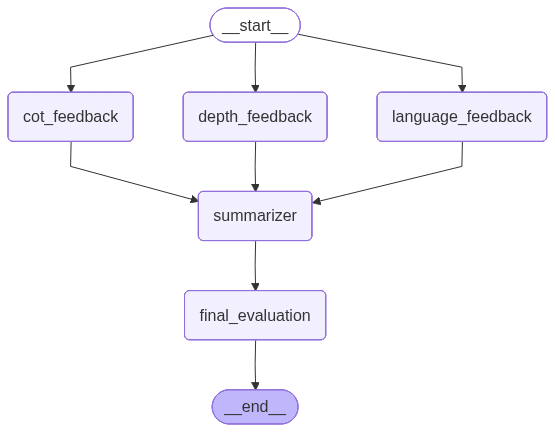

In [ ]:
graph = StateGraph(EssayState)

graph.add_node("cot_feedback", cot_feedback)
graph.add_node("language_feedback", language_feedback)
graph.add_node("depth_feedback", depth_feedback)

graph.add_node("summarizer", summarize_feedback)
graph.add_node("final_evaluation", final_evaluation)


graph.add_edge(START, "cot_feedback")
graph.add_edge(START, "language_feedback")
graph.add_edge(START, "depth_feedback")


graph.add_edge("cot_feedback", "summarizer")
graph.add_edge("language_feedback", "summarizer")
graph.add_edge("depth_feedback", "summarizer")

graph.add_edge("summarizer", "final_evaluation")

graph.add_edge("final_evaluation", END)

workflow = graph.compile()


workflow

In [13]:
essay_text = """
Technology is transforming education in India.
It has improved accessibility and learning outcomes.
However, challenges such as the digital divide,
teacher training and infrastructure remain.
Balanced adoption is necessary.
"""

result = workflow.invoke(
    {
        "essay": essay_text,
        "feedbacks": []
    }
)


print("\nFINAL EVALUATION\n")

print(result["final_evaluation"])


FINAL EVALUATION

overall_score=4 strengths=['Clear identification of the core topic and its dual aspects (positives and challenges).', 'Grammatically sound and highly readable language.', 'Appropriate and relevant vocabulary used.'] weaknesses=['Extreme brevity and lack of depth, making it an outline rather than an essay.', 'Absence of a proper introduction, conclusion, or structured body paragraphs.', 'Lack of specific examples, case studies, data, or historical context.', 'Superficial analysis and limited multidimensional thinking.', 'Language, while correct, lacks the complexity and sophistication required for UPSC.'] action_items=['Significantly expand on each point with detailed analysis, specific examples (e.g., SWAYAM, DIKSHA), case studies, and relevant data/statistics.', 'Develop a clear essay structure including a comprehensive introduction with a thesis statement, well-elaborated body paragraphs, and a strong conclusion with policy recommendations.', 'Incorporate historica